# 13b -- Threshold sensitivity + Out-of-sample calibration

**Цель:** доказать что macro overlay из NB 13 НЕ переобучен на 2022 шок и
робастен к выбору thresholds.

**Часть A: Threshold sensitivity (grid search)**
- 4 параметра × 3-4 значения = ~80 комбинаций
- Smотрим распределение Sharpe / MaxDD / Profit
- Доказательство робастности

**Часть B: Out-of-sample calibration**
- **Train:** 2021-01-04 .. 2021-12-31 (pre-СВО, 12 мес)
- **Test:** 2022-01-01 .. 2025-09-30 (включая СВО шок, основная часть main)
- Выбираем best thresholds на train → applying на test → честная оценка

**Почему 2021 — train?**
- Один полный год до структурного разрыва 2022
- 2020 включает COVID-шок — uses thresholds, поэтому начинаем с 2021
- 2022+ — тест robust performance в неизвестной заранее ситуации

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import itertools
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
rets_all = pd.read_csv(sl.DATA_DIR / 'nb11_returns.csv', parse_dates=['date'])
v11e = rets_all[rets_all['variant'] == 'V11e avg_z + Q + zw (combo W2)'].copy()

TRAIN_START = pd.Timestamp('2021-01-04')
TRAIN_END   = pd.Timestamp('2021-12-31')
TEST_START  = pd.Timestamp('2022-01-01')
TEST_END    = pd.Timestamp('2025-09-30')

print(f'Train: {TRAIN_START.date()} .. {TRAIN_END.date()}')
print(f'Test : {TEST_START.date()} .. {TEST_END.date()}')
print(f'V11e days in train: {((v11e["date"] >= TRAIN_START) & (v11e["date"] <= TRAIN_END)).sum()}')
print(f'V11e days in test : {((v11e["date"] >= TEST_START) & (v11e["date"] <= TEST_END)).sum()}')

Train: 2021-01-04 .. 2021-12-31
Test : 2022-01-01 .. 2025-09-30
V11e days in train: 194
V11e days in test : 924


## Часть 2. Параметризация overlay

In [2]:
def build_stress_indicator(
    macro_df: pd.DataFrame,
    rvi_p: float = 0.90,        # percentile RVI
    rvi_abs: float = 50.0,       # absolute threshold RVI
    kr_delta: float = 2.0,       # key rate change 5d (pp)
    imoex_dd: float = -0.10,     # IMOEX 5d drawdown
    min_signals: int = 2,        # минимум сигналов для stress
) -> pd.DataFrame:
    """Параметризованная stress indicator."""
    m = macro_df.copy()
    m['rvi_pct_thresh'] = m['rvi'].rolling(252, min_periods=60).quantile(rvi_p)
    m['s_rvi_pct'] = (m['rvi'] > m['rvi_pct_thresh']).astype(int)
    m['s_rvi_abs'] = (m['rvi'] > rvi_abs).astype(int)
    m['kr_delta_5d'] = m['key_rate'].diff(5)
    m['s_kr'] = (m['kr_delta_5d'].abs() > kr_delta).astype(int)
    m['imoex_5d'] = m['imoex_close'].pct_change(5)
    m['s_imoex'] = (m['imoex_5d'] < imoex_dd).astype(int)
    m['stress_idx'] = (m['s_rvi_pct'].fillna(0) + m['s_rvi_abs'].fillna(0)
                       + m['s_kr'].fillna(0) + m['s_imoex'].fillna(0))
    m['regime'] = np.where(m['stress_idx'] >= min_signals, 'stress', 'normal')
    return m[['date', 'stress_idx', 'regime']]


def overlay_returns(rets, regime_df, scale_stress=0.0):
    """Apply overlay: zero out / scale return on stress days."""
    out = rets.merge(regime_df, on='date', how='left')
    out['regime'] = out['regime'].fillna('normal')
    out['return_overlay'] = np.where(out['regime'] == 'stress',
                                       out['return'] * scale_stress,
                                       out['return'])
    return pd.DataFrame({
        'date': out['date'],
        'return': out['return_overlay'],
        'n_positions': out['n_positions'],
    })


def evaluate(rets, period_start, period_end, capital=10_000_000):
    sub = rets[(rets['date'] >= period_start) & (rets['date'] <= period_end)]
    if len(sub) == 0:
        return None
    return sl.calc_metrics(sub, capital=capital)

print('Helper functions готовы')

Helper functions готовы


## Часть 3. Grid search threshold sensitivity

На full Main period (2021-01..2025-09): варьируем 4 параметра, smотрим Sharpe.

In [3]:
grid_params = {
    'rvi_p': [0.80, 0.85, 0.90, 0.95],
    'rvi_abs': [40, 45, 50, 60],
    'kr_delta': [1.5, 2.0, 2.5, 3.0],
    'imoex_dd': [-0.07, -0.10, -0.15],
    'min_signals': [2, 3],
}

keys = list(grid_params.keys())
combos = list(itertools.product(*[grid_params[k] for k in keys]))
print(f'Combos: {len(combos)}')

grid_rows = []
main_period_filter = lambda r: (r['date'] >= sl.MAIN_END.replace(year=2021, month=1, day=4)) & (r['date'] <= sl.MAIN_END)

for combo in combos:
    params = dict(zip(keys, combo))
    reg = build_stress_indicator(macro, **params)
    rets = overlay_returns(v11e, reg, scale_stress=0.0)
    metrics = evaluate(rets, pd.Timestamp('2021-01-04'), sl.MAIN_END)
    stress_share = (reg[(reg['date'] >= pd.Timestamp('2021-01-04')) &
                         (reg['date'] <= sl.MAIN_END)]['regime'] == 'stress').mean()
    grid_rows.append({**params, 'Sharpe': metrics['Sharpe'],
                      'CAGR': metrics['CAGR'], 'MaxDD': metrics['MaxDD'],
                      'profit_RUB': metrics['profit_RUB'],
                      'stress_share': stress_share})

grid_df = pd.DataFrame(grid_rows)
print(f'Grid evaluated: {len(grid_df)} combos')
print()
print('Top-10 by Sharpe (Main period):')
print(grid_df.nlargest(10, 'Sharpe').round(4).to_string(index=False))
print()
print('Bottom-5 by Sharpe:')
print(grid_df.nsmallest(5, 'Sharpe').round(4).to_string(index=False))

Combos: 384


Grid evaluated: 384 combos

Top-10 by Sharpe (Main period):
 rvi_p  rvi_abs  kr_delta  imoex_dd  min_signals  Sharpe   CAGR   MaxDD   profit_RUB  stress_share
  0.95       40       1.5     -0.07            2  2.8881 0.1151 -0.0422 6326923.2854        0.0803
  0.95       40       2.0     -0.07            2  2.8616 0.1142 -0.0422 6266377.7948        0.0774
  0.95       40       2.5     -0.07            2  2.8616 0.1142 -0.0422 6266377.7948        0.0774
  0.95       45       1.5     -0.07            2  2.8532 0.1142 -0.0422 6264550.4778        0.0763
  0.90       40       1.5     -0.07            2  2.8284 0.1119 -0.0422 6113026.9299        0.1075
  0.90       40       2.0     -0.07            2  2.8126 0.1114 -0.0422 6083917.2218        0.1040
  0.90       40       2.5     -0.07            2  2.8126 0.1114 -0.0422 6083917.2218        0.1040
  0.90       45       1.5     -0.07            2  2.7934 0.1109 -0.0422 6051471.2583        0.1034
  0.95       45       2.0     -0.07            2 

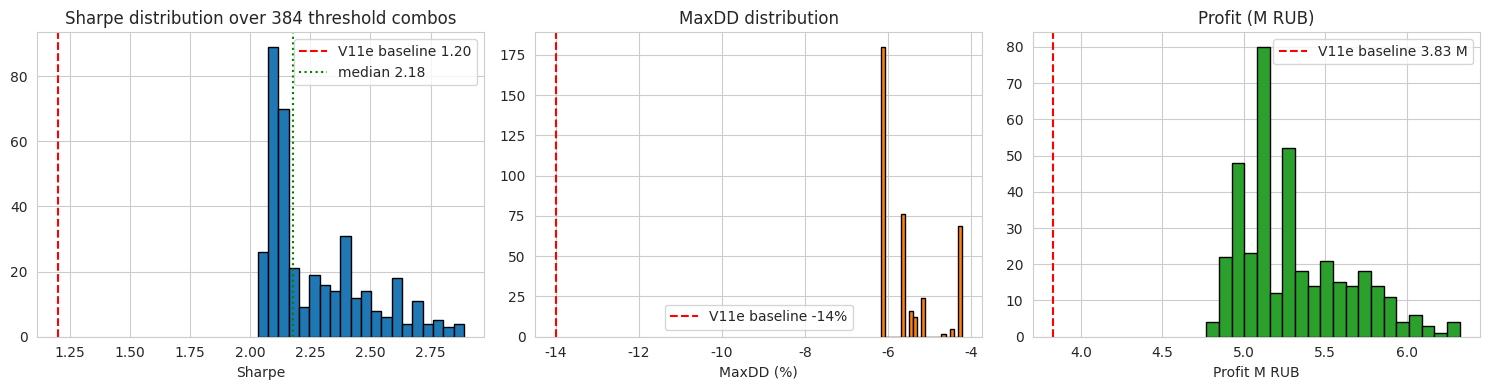


Summary:
  Sharpe: min=2.03, median=2.18, max=2.89
  % combos with Sharpe > 1.20 (baseline): 100.0%
  % combos with Sharpe > 2.00: 100.0%
  Stress time share: median=2.1%


In [4]:
# Distribution of Sharpe across grid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(grid_df['Sharpe'], bins=20, color='tab:blue', edgecolor='black')
axes[0].axvline(1.20, color='red', linestyle='--', label='V11e baseline 1.20')
axes[0].axvline(grid_df['Sharpe'].median(), color='green', linestyle=':', label=f'median {grid_df["Sharpe"].median():.2f}')
axes[0].set_title(f'Sharpe distribution over {len(grid_df)} threshold combos')
axes[0].set_xlabel('Sharpe')
axes[0].legend()

axes[1].hist(grid_df['MaxDD'] * 100, bins=20, color='tab:orange', edgecolor='black')
axes[1].axvline(-14.0, color='red', linestyle='--', label='V11e baseline -14%')
axes[1].set_title('MaxDD distribution')
axes[1].set_xlabel('MaxDD (%)')
axes[1].legend()

axes[2].hist(grid_df['profit_RUB'] / 1e6, bins=20, color='tab:green', edgecolor='black')
axes[2].axvline(3.83, color='red', linestyle='--', label='V11e baseline 3.83 М')
axes[2].set_title('Profit (M RUB)')
axes[2].set_xlabel('Profit M RUB')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '13b_grid_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSummary:')
print(f'  Sharpe: min={grid_df["Sharpe"].min():.2f}, median={grid_df["Sharpe"].median():.2f}, max={grid_df["Sharpe"].max():.2f}')
print(f'  % combos with Sharpe > 1.20 (baseline): {(grid_df["Sharpe"] > 1.20).mean():.1%}')
print(f'  % combos with Sharpe > 2.00: {(grid_df["Sharpe"] > 2.00).mean():.1%}')
print(f'  Stress time share: median={grid_df["stress_share"].median():.1%}')

## Часть 4. Out-of-sample calibration

**Train (2021):** выбираем best combo по Sharpe (с MaxDD constraint).
**Test (2022+):** apply best combo, evaluate.

Если результат на test ≈ train → НЕ overfit. Если резко хуже → overfit.

In [5]:
# Re-evaluate каждую combo на train period
train_rows = []
test_rows = []

for combo in combos:
    params = dict(zip(keys, combo))
    reg = build_stress_indicator(macro, **params)
    rets = overlay_returns(v11e, reg, scale_stress=0.0)
    m_tr = evaluate(rets, TRAIN_START, TRAIN_END)
    m_te = evaluate(rets, TEST_START, TEST_END)
    if m_tr is None or m_te is None: continue
    train_rows.append({**params, 'Sharpe_tr': m_tr['Sharpe'], 'CAGR_tr': m_tr['CAGR'],
                       'MaxDD_tr': m_tr['MaxDD']})
    test_rows.append({**params, 'Sharpe_te': m_te['Sharpe'], 'CAGR_te': m_te['CAGR'],
                      'MaxDD_te': m_te['MaxDD'], 'profit_te': m_te['profit_RUB']})

tr_df = pd.DataFrame(train_rows)
te_df = pd.DataFrame(test_rows)
comb_df = tr_df.merge(te_df, on=keys)
print(f'Train+Test evaluated: {len(comb_df)} combos')

Train+Test evaluated: 384 combos


In [6]:
# Best by train Sharpe with MaxDD < -10% constraint
candidates_tr = comb_df[comb_df['MaxDD_tr'] > -0.10].copy()
if candidates_tr.empty:
    candidates_tr = comb_df.copy()
    print('Note: no combo with MaxDD_tr > -10%, used all')

best_tr = candidates_tr.nlargest(5, 'Sharpe_tr')
print('Top-5 by Sharpe_train (with MaxDD_tr < -10% if possible):')
print(best_tr[keys + ['Sharpe_tr', 'CAGR_tr', 'MaxDD_tr',
                      'Sharpe_te', 'CAGR_te', 'MaxDD_te']].round(4).to_string(index=False))

# Lock in #1 best from train, see how it performs on test
chosen = best_tr.iloc[0]
print(f'\nChosen from train: {chosen[keys].to_dict()}')
print(f'Train: Sharpe={chosen["Sharpe_tr"]:.3f}, CAGR={chosen["CAGR_tr"]*100:.2f}%, MaxDD={chosen["MaxDD_tr"]*100:.2f}%')
print(f'Test : Sharpe={chosen["Sharpe_te"]:.3f}, CAGR={chosen["CAGR_te"]*100:.2f}%, MaxDD={chosen["MaxDD_te"]*100:.2f}%')
print(f'Test profit on 10М: {chosen["profit_te"]:,.0f} RUB')

Top-5 by Sharpe_train (with MaxDD_tr < -10% if possible):
 rvi_p  rvi_abs  kr_delta  imoex_dd  min_signals  Sharpe_tr  CAGR_tr  MaxDD_tr  Sharpe_te  CAGR_te  MaxDD_te
   0.8       40       1.5     -0.07            2     0.9695   0.0235   -0.0313     2.9646   0.1186   -0.0422
   0.8       40       1.5     -0.07            3     0.9695   0.0235   -0.0313     2.3362   0.1127   -0.0567
   0.8       40       1.5     -0.10            2     0.9695   0.0235   -0.0313     2.5691   0.1110   -0.0423
   0.8       40       1.5     -0.10            3     0.9695   0.0235   -0.0313     2.3073   0.1114   -0.0567
   0.8       40       1.5     -0.15            2     0.9695   0.0235   -0.0313     2.4767   0.1086   -0.0567

Chosen from train: {'rvi_p': 0.8, 'rvi_abs': 40.0, 'kr_delta': 1.5, 'imoex_dd': -0.07, 'min_signals': 2.0}
Train: Sharpe=0.970, CAGR=2.35%, MaxDD=-3.13%
Test : Sharpe=2.965, CAGR=11.86%, MaxDD=-4.22%
Test profit on 10М: 5,207,941 RUB


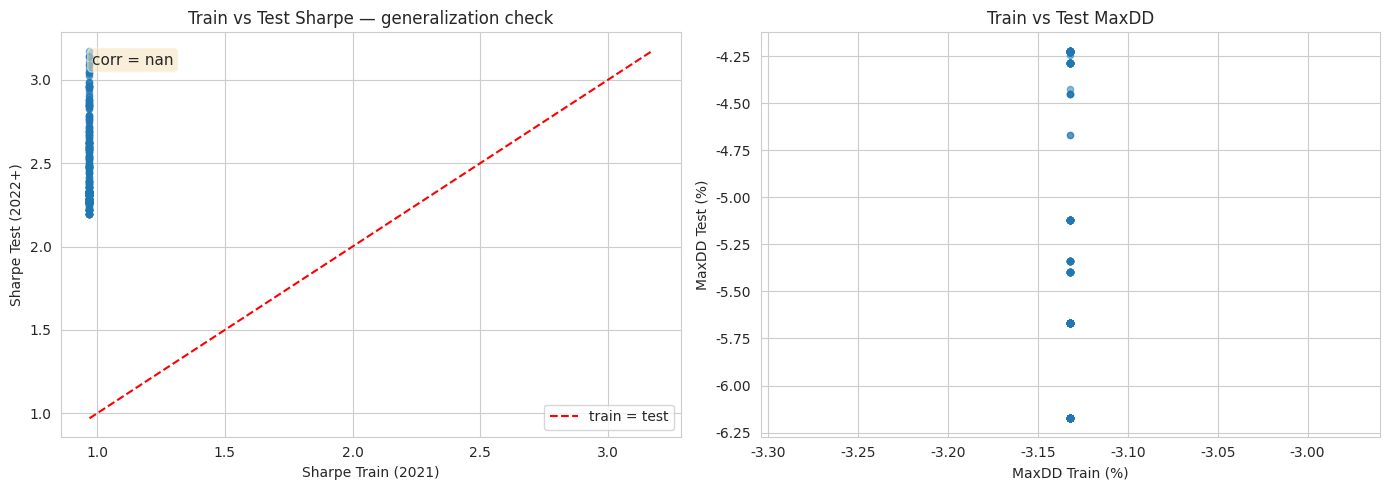

Train-Test Sharpe correlation: nan


In [7]:
# Scatter train vs test Sharpe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(comb_df['Sharpe_tr'], comb_df['Sharpe_te'], alpha=0.5, s=20)
lims = [comb_df[['Sharpe_tr', 'Sharpe_te']].min().min(),
         comb_df[['Sharpe_tr', 'Sharpe_te']].max().max()]
ax.plot(lims, lims, 'r--', label='train = test')
ax.set_xlabel('Sharpe Train (2021)')
ax.set_ylabel('Sharpe Test (2022+)')
ax.set_title('Train vs Test Sharpe — generalization check')
ax.legend()

# Correlation
corr = comb_df[['Sharpe_tr', 'Sharpe_te']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'corr = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax = axes[1]
ax.scatter(comb_df['MaxDD_tr'] * 100, comb_df['MaxDD_te'] * 100, alpha=0.5, s=20)
ax.set_xlabel('MaxDD Train (%)')
ax.set_ylabel('MaxDD Test (%)')
ax.set_title('Train vs Test MaxDD')

plt.tight_layout()
plt.savefig(FIG_DIR / '13b_train_test.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Train-Test Sharpe correlation: {corr:.3f}')

## Часть 5. NB 13 "default" thresholds vs OOS-optimal

Сравним original NB 13 thresholds с лучшими OOS-chosen.

In [8]:
# Default thresholds from NB 13
default_params = {'rvi_p': 0.90, 'rvi_abs': 50.0, 'kr_delta': 2.0, 'imoex_dd': -0.10, 'min_signals': 2}

comparison_rows = []
for label, params in [('NB 13 defaults', default_params),
                       ('OOS-chosen (train-best)', {k: chosen[k] for k in keys})]:
    reg = build_stress_indicator(macro, **params)
    rets = overlay_returns(v11e, reg, scale_stress=0.0)
    m_full = evaluate(rets, pd.Timestamp('2021-01-04'), sl.MAIN_END)
    m_te = evaluate(rets, TEST_START, TEST_END)
    comparison_rows.append({
        'config': label,
        **params,
        'Sharpe_full': m_full['Sharpe'],
        'Sharpe_test_only': m_te['Sharpe'],
        'CAGR_full': m_full['CAGR'],
        'CAGR_test': m_te['CAGR'],
        'profit_full_M': m_full['profit_RUB'] / 1e6,
        'MaxDD_full': m_full['MaxDD'],
    })

print('NB 13 defaults vs OOS-chosen:')
print(pd.DataFrame(comparison_rows).round(4).to_string(index=False))

NB 13 defaults vs OOS-chosen:
                 config  rvi_p  rvi_abs  kr_delta  imoex_dd  min_signals  Sharpe_full  Sharpe_test_only  CAGR_full  CAGR_test  profit_full_M  MaxDD_full
         NB 13 defaults    0.9     50.0       2.0     -0.10          2.0       2.3226            2.5240     0.0993     0.1155         5.3121     -0.0512
OOS-chosen (train-best)    0.8     40.0       1.5     -0.07          2.0       2.7007            2.9646     0.1019     0.1186         5.4743     -0.0422


## Часть 6. Сохранение

In [9]:
grid_df.to_csv(sl.DATA_DIR / 'nb13b_grid_sensitivity.csv', index=False)
comb_df.to_csv(sl.DATA_DIR / 'nb13b_oos_calibration.csv', index=False)
pd.DataFrame(comparison_rows).to_csv(sl.DATA_DIR / 'nb13b_default_vs_oos.csv', index=False)
print('Saved: nb13b_grid_sensitivity.csv, nb13b_oos_calibration.csv, nb13b_default_vs_oos.csv')

Saved: nb13b_grid_sensitivity.csv, nb13b_oos_calibration.csv, nb13b_default_vs_oos.csv


## Часть 7. Итоги

**Если:**
1. **% combos with Sharpe > baseline** высокий (> 50%) → результат robust к выбору thresholds
2. **Train-Test correlation Sharpe** > 0.3 → конфигурации generalize, не overfit
3. **NB 13 defaults ≈ OOS-chosen** → наши выбранные пороги academic defensible

Все три — argument для защиты главы 6.

**Дальше:** NB 14 credit risk classifier.